In [93]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Models
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
# Utils
import warnings
warnings.filterwarnings("ignore")


In [2]:
# Load dataset
df = pd.read_csv("water_quality.csv", encoding="latin1")


In [3]:
df.head(4)

,STN Code,Sampling Date,Month,Sampling Time,Stn Name,Type Water Body,Name Of Water Body,River Basin,District,State Name,...,Total Dissolved Solids,Total Fixed Solids,Total Suspended Solids,Phosphate,Boron,Potassium,Flouride,Remark,latitude,longitude
0,1312,08-05-2025,Aug,16:30:00,"Godavari river at Jaikwadi Dam, Village. Paith...",River,Godavari,Godavari,Ch. Sambhaji Nagar,Maharashtra,...,497.0,448.0,10(BDL),0.78,0.58,2.88,0.5,NaN,19°29.263',75°22.272'
1,2158,08-05-2025,Aug,16:00:00,Godavari river at U/s of Paithan at Paithan in...,River,Godavari,Godavari,Ch. Sambhaji Nagar,Maharashtra,...,489.0,441.0,11,0.71,0.61,3.14,0.41,NaN,19°30.887,75°22.457
2,2159,08-05-2025,Aug,17:15:00,Godavari river at D/s of Paithan at Pathegaon ...,River,Godavari,Godavari,Ch. Sambhaji Nagar,Maharashtra,...,491.0,442.0,11,0.76,0.56,3.16,0.45,NaN,19°28.835,75°23.835
3,2160,08-05-2025,Aug,15:00:00,"Godavari river at U/s of Aurangabad Reservoir,...",River,Godavari,Godavari,Ch. Sambhaji Nagar,Maharashtra,...,479.0,612.0,10(BDL),1.47,0.55,3.13,0.6,NaN,19°37.463,75°01.490


In [4]:
# Basic dataset checks
print("Shape:", df.shape)

Shape: (222, 54)


In [5]:
print("\nColumns:\n", df.columns.tolist())


Columns:
 ['STN Code', 'Sampling Date', 'Month', 'Sampling Time', 'Stn Name', 'Type Water Body', 'Name Of Water Body', 'River Basin', 'District', 'State Name', 'Mon Agency', 'Frequency', 'Major Polluting Sources', 'Use Based Class', ' Use of Water in Down Stream', ' Visibility Effluent Discharge', 'Weather', 'Approx Depth', 'Human Activities', 'Floating Matter', 'Color', 'Odor', 'Flow', 'Temperature', 'Dissolved O2', 'pH', 'Conductivity', 'BOD', 'Nitrate N', 'Fecal Coliform', 'Total Coliform', 'Fecal Streptococci', 'Turbidity', 'Phenophelene Alkanity', 'Total Alkalinity', 'Chlorides', 'COD', 'Total Kjeldahl N', 'Amonia N', 'Hardness CaCo3', 'Calcium CaCo3', 'Magnesium CaCo3', 'Sulphate', 'Sodium', 'Total Dissolved Solids', 'Total Fixed Solids', 'Total Suspended Solids', 'Phosphate', 'Boron', 'Potassium', 'Flouride', 'Remark', 'latitude', 'longitude']


Data Preprocessing

In [6]:
# Dropping non-ML columns: identifiers, location data, dates, text fields, and descriptive metadata
# These do not contribute to water quality prediction and are not suitable as model features

drop_cols = [
    "STN Code", "Sampling Date", "Month", "Sampling Time",
    "Stn Name", "Type Water Body", "Name Of Water Body",
    "River Basin", "District", "State Name",
    "Mon Agency", "Frequency", "Major Polluting Sources",
    "Use Based Class", " Use of Water in Down Stream",
    " Visibility Effluent Discharge", "Weather",
    "Human Activities", "Floating Matter",
    "Color", "Odor", "Flow", "Remark",
    "latitude", "longitude"
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])

print("Shape after drop:", df.shape)


Shape after drop: (222, 29)


In [7]:
df.head(4)

,Approx Depth,Temperature,Dissolved O2,pH,Conductivity,BOD,Nitrate N,Fecal Coliform,Total Coliform,Fecal Streptococci,...,Magnesium CaCo3,Sulphate,Sodium,Total Dissolved Solids,Total Fixed Solids,Total Suspended Solids,Phosphate,Boron,Potassium,Flouride
0,Greater than 100cm,28.0,6.7,8.4,575.0,3.2,0.54,1.8(BDL),35,1.8(BDL),...,80.0,72,60.44,497.0,448.0,10(BDL),0.78,0.58,2.88,0.5
1,Greater than 100cm,28.0,6.6,8.3,576.0,3.2,0.52,1.8(BDL),25,1.8(BDL),...,76.0,68.88,61.1,489.0,441.0,11,0.71,0.61,3.14,0.41
2,Greater than 100cm,28.0,6.9,8.5,573.0,3.2,0.56,1.8(BDL),20,1.8(BDL),...,78.0,68.54,67.84,491.0,442.0,11,0.76,0.56,3.16,0.45
3,Greater than 100cm,28.0,7,7.9,592.0,3.4,0.58,1.8(BDL),13,1.8(BDL),...,68.0,73.3,55.38,479.0,612.0,10(BDL),1.47,0.55,3.13,0.6


In [8]:
df.columns

Index(['Approx Depth', 'Temperature', 'Dissolved O2', 'pH', 'Conductivity',
       'BOD', 'Nitrate N', 'Fecal Coliform', 'Total Coliform',
       'Fecal Streptococci', 'Turbidity', 'Phenophelene Alkanity',
       'Total Alkalinity', 'Chlorides', 'COD', 'Total Kjeldahl N', 'Amonia N',
       'Hardness CaCo3', 'Calcium CaCo3', 'Magnesium CaCo3', 'Sulphate',
       'Sodium', 'Total Dissolved Solids', 'Total Fixed Solids',
       'Total Suspended Solids', 'Phosphate', 'Boron', 'Potassium',
       'Flouride'],
      dtype='object')

In [9]:
#data pre-processing 
#Approx Depth
df['Approx Depth'].value_counts()


Approx Depth
Less than 50cm        188
Greater than 100cm     16
50-100cm               11
Name: count, dtype: int64

In [10]:
#shape of data frame
df.shape

(222, 29)

In [11]:
# Clean text formatting first
df["Approx Depth"] = df["Approx Depth"].astype(str).str.strip()

# Map depth categories to numeric values (cm)
depth_map = {
    "Less than 50cm": 25,
    "50-100cm": 75,
    "Greater than 100cm": 125
}

df["Approx Depth"] = df["Approx Depth"].map(depth_map)

In [12]:
# Check unique values
df["Approx Depth"].value_counts()

Approx Depth
25.0     188
125.0     16
75.0      11
Name: count, dtype: int64

In [13]:
df['Temperature'].value_counts()

Temperature
28.0    48
26.0    32
27.0    21
29.0    14
22.0    13
27.5    12
24.0     9
23.0     8
20.0     8
30.0     7
18.0     7
25.0     7
31.0     3
21.0     3
19.0     1
Name: count, dtype: int64

In [14]:
#Dissolved column 
df['Dissolved O2'].unique()

array(['6.7', '6.6', '6.9', '7', '7.1', '6.8', '6', '6.4', '5.3', '7.7',
       '7.4', '5.9', '6.1', '6.2', '7.2', '4.4', '4.6', '5', '4.2',
       '0.3(BDL)', '4.8', '1', '0.9', '5.2', '3.9', '4', '7.3', '4.5',
       '4.3', '5.6', '5.1', '7.6', '1.2', '1.6', '5.8', '5.4', '4.1', '3',
       '4.7', '5.5', nan, '2.4', '2.2', '2.1', '1.3', '3.2', '3.8', '6.3',
       '3.4', '3.5', '4.9'], dtype=object)

In [15]:
# clean BDL text
df["Dissolved O2"] = df["Dissolved O2"].replace(r"\(BDL\)", "", regex=True)

# strip spaces
df["Dissolved O2"] = df["Dissolved O2"].astype(str).str.strip()


In [16]:
#pH column has no cleaning to be done
df['pH'].unique()

array([8.4, 8.3, 8.5, 7.9, 8.7, 8.6, 8.1, 9. , 7.8, 7.7, 7.6, 8. , 7.3,
       7.4, 7.2, 7.5, 7.1, 6.9, 8.2, 9.7, 9.1, 9.3, nan])

In [17]:
#Conductivity dont need cleaning
df['Conductivity'].value_counts()

Conductivity
575.0    3
721.0    3
506.0    2
130.0    2
153.0    2
        ..
610.0    1
816.0    1
796.0    1
587.0    1
734.0    1
Name: count, Length: 196, dtype: int64

In [18]:
#BOD does not need cleaning
df['BOD'].unique()

array([  3.2,   3.4,   3.8,   3. ,   3.6,   4.8,   2.8,   2.6,  12. ,
        14. ,  13. ,   2.4,  16. ,   8. ,  38. ,  44. ,  30. ,  35. ,
         4.6,   8.4,   4.4,   7.4,   2. ,  18. ,  54. ,  58. , 110. ,
       210. ,  12.5,   4. ,   1.8,   4.2,   4.1,   4.7,   9.1,  31. ,
         3.5,  32.6,  24.8,  13.9,  11.2,   4.5,   4.9,   3.7,   3.3,
         6. ,   6.2,   8.8,   8.6,   5.4,   5.6,   nan,  27. ,   7.2,
         7. ,   5. ,  28. ,  26. ,  13.5,   6.4,   7.8,  15. ,   9.5,
         5.2,   7.6,   8.2])

In [19]:
#these cloumns need to be processsed since they have numeric and text data
dirty_cols = df.select_dtypes(include="object").columns
dirty_cols

Index(['Dissolved O2', 'Nitrate N', 'Fecal Coliform', 'Total Coliform',
       'Fecal Streptococci', 'Turbidity', 'Phenophelene Alkanity',
       'Total Alkalinity', 'Chlorides', 'Total Kjeldahl N', 'Sulphate',
       'Sodium', 'Total Suspended Solids', 'Phosphate', 'Boron', 'Potassium',
       'Flouride'],
      dtype='object')

In [20]:
#Nitrate column has text,and ND which is no data to be handled
df['Nitrate N'].unique()

array(['0.54', '0.52', '0.56', '0.58', '0.63', '0.7', '1.8', '1.95',
       '3.2', '2.1', '1.74', '0.74', '0.66', '1.14', '1.15', '0.78',
       '0.91', '0.97', '1.35', '1.12', '1.24', '1.45', '1.1', '0.55',
       '0.3(BDL)', '0.34', '0.47', '0.51', '0.4', '1.47', '0.59', '0.95',
       '0.93', '1', '0.94', '1.93', '1.32', '1.98', '2.09', '2', '0.85',
       '0.83', '1.03', '0.96', '0.87', '0.62', '0.65', '3.82', '2.29',
       '21', '1.41', '2.16', '0.68', '0.69', '0.72', '0.53', '0.45',
       '0.37', '0.41', '0.49', '0.89', '0.8', '0.38', '1.33', '0.31',
       '1.29', '1.4', '3.5', '2.66', '0.76', '1.6', '1.19', '1.79',
       '2.08', '2.32', '1.09', '3.66', '3.62', '0.99', '0.71', '0.64',
       '3.7', '3.79', 'ND', '2.55', '3.81', '3.67', '3.83', '2.56',
       '2.65', '4.92', '4.28', '2.49', '2.45', '2.53', '2.72', '2.77',
       '1.65', '1.54', '2.23', nan, '2.9', '3', '1.11', '2.74', '2.67',
       '2.6', '1.83', '0.6', '2.36', '0.61', '2.21', '3.11', '1.84',
       '0.92', '

In [21]:
# clean Nitrate N column
df["Nitrate N"] = df["Nitrate N"].astype(str).str.strip()#strip spaces
df["Nitrate N"] = df["Nitrate N"].replace(r"\(BDL\)", "", regex=True)#remove BDL
df["Nitrate N"] = df["Nitrate N"].replace("ND", np.nan)#replace ND with nan


In [22]:
#fecal coliform 
df['Fecal Coliform'].unique()

array(['1.8(BDL)', '5.6', '5.5', '9.3', '6.8', '9.2', '6.1', '8.3', '8.1',
       '4.5', '6', '27', '32', '13', '14', '23', '220', '140', '430',
       '280', '94', '130', '1400', '110', '170', '70', '63', '33', '40',
       '4', '17', '38', '2', '79', '49', '1600', '46', '12', '25', '15',
       nan, '10', '21', '26', '20', '41', '120', '240', '540', '48', '11',
       '350'], dtype=object)

In [23]:
#we found BDL is text that exists randomly everywhere so we remove the BDL from whole data frame
df = df.replace(r"\(BDL\)", "", regex=True)
#replace if empty string with nan if it exists
df = df.replace("", np.nan)

In [24]:
#cheking waeather we still have the any text in data
for col in df.columns:
    print(f"\n--- {col} ---")
    print(df[col].unique())



--- Approx Depth ---
[125.  25.  75.  nan]

--- Temperature ---
[28.  29.  30.  20.  22.  31.  18.  19.  26.  27.   nan 21.  25.  24.
 23.  27.5]

--- Dissolved O2 ---
['6.7' '6.6' '6.9' '7' '7.1' '6.8' '6' '6.4' '5.3' '7.7' '7.4' '5.9' '6.1'
 '6.2' '7.2' '4.4' '4.6' '5' '4.2' '0.3' '4.8' '1' '0.9' '5.2' '3.9' '4'
 '7.3' '4.5' '4.3' '5.6' '5.1' '7.6' '1.2' '1.6' '5.8' '5.4' '4.1' '3'
 '4.7' '5.5' 'nan' '2.4' '2.2' '2.1' '1.3' '3.2' '3.8' '6.3' '3.4' '3.5'
 '4.9']

--- pH ---
[8.4 8.3 8.5 7.9 8.7 8.6 8.1 9.  7.8 7.7 7.6 8.  7.3 7.4 7.2 7.5 7.1 6.9
 8.2 9.7 9.1 9.3 nan]

--- Conductivity ---
[5.750e+02 5.760e+02 5.730e+02 5.920e+02 9.220e+02 3.560e+02 5.060e+02
 5.260e+02 7.210e+02 4.090e+02 4.130e+02 3.320e+02 4.231e+03 1.690e+02
 1.670e+02 9.200e+01 1.300e+02 1.530e+02 1.420e+02 9.600e+01 1.440e+02
 3.336e+03 2.244e+03 2.618e+03 2.725e+03 2.348e+03 1.290e+02 7.500e+01
 6.550e+02 4.712e+04 4.648e+04 2.967e+04 2.390e+02 1.050e+02 1.060e+02
 8.400e+01 8.900e+01 1.480e+02 2.250e+02 3.114e

In [25]:
for col in df.columns:
    print(col, "→", df[col].dtype)


Approx Depth → float64
Temperature → float64
Dissolved O2 → object
pH → float64
Conductivity → float64
BOD → float64
Nitrate N → object
Fecal Coliform → object
Total Coliform → object
Fecal Streptococci → object
Turbidity → object
Phenophelene Alkanity → object
Total Alkalinity → object
Chlorides → object
COD → float64
Total Kjeldahl N → object
Amonia N → float64
Hardness CaCo3 → float64
Calcium CaCo3 → float64
Magnesium CaCo3 → float64
Sulphate → object
Sodium → object
Total Dissolved Solids → float64
Total Fixed Solids → float64
Total Suspended Solids → object
Phosphate → object
Boron → object
Potassium → object
Flouride → object


In [26]:
#converting columns to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")


In [27]:
#checking column data type
for col in df.columns:
    print(col, "→", df[col].dtype)


Approx Depth → float64
Temperature → float64
Dissolved O2 → float64
pH → float64
Conductivity → float64
BOD → float64
Nitrate N → float64
Fecal Coliform → float64
Total Coliform → float64
Fecal Streptococci → float64
Turbidity → float64
Phenophelene Alkanity → float64
Total Alkalinity → float64
Chlorides → float64
COD → float64
Total Kjeldahl N → float64
Amonia N → float64
Hardness CaCo3 → float64
Calcium CaCo3 → float64
Magnesium CaCo3 → float64
Sulphate → float64
Sodium → float64
Total Dissolved Solids → float64
Total Fixed Solids → float64
Total Suspended Solids → float64
Phosphate → float64
Boron → float64
Potassium → float64
Flouride → float64


In [28]:
# fill missing values using median
# median is stable for scientific data and handles outliers well
df = df.fillna(df.median())

# check if any NaN left
print("Remaining NaN count:\n", df.isna().sum())


Remaining NaN count:
 Approx Depth              0
Temperature               0
Dissolved O2              0
pH                        0
Conductivity              0
BOD                       0
Nitrate N                 0
Fecal Coliform            0
Total Coliform            0
Fecal Streptococci        0
Turbidity                 0
Phenophelene Alkanity     0
Total Alkalinity          0
Chlorides                 0
COD                       0
Total Kjeldahl N          0
Amonia N                  0
Hardness CaCo3            0
Calcium CaCo3             0
Magnesium CaCo3           0
Sulphate                  0
Sodium                    0
Total Dissolved Solids    0
Total Fixed Solids        0
Total Suspended Solids    0
Phosphate                 0
Boron                     0
Potassium                 0
Flouride                  0
dtype: int64


In [29]:
# create water quality class based on key pollution indicators
def classify_water(row):
    score = 0

    # -------------------------------
    # Core pollution indicators
    # -------------------------------

    # Biological Oxygen Demand (organic pollution)
    if row["BOD"] > 10:
        score += 2
    elif row["BOD"] > 5:
        score += 1

    # Chemical Oxygen Demand (chemical pollution)
    if row["COD"] > 50:
        score += 2
    elif row["COD"] > 25:
        score += 1

    # Dissolved Oxygen (ecological health)
    if row["Dissolved O2"] < 3:
        score += 2
    elif row["Dissolved O2"] < 5:
        score += 1

    # Total Dissolved Solids (salinity + chemical load)
    if row["Total Dissolved Solids"] > 1000:
        score += 2
    elif row["Total Dissolved Solids"] > 500:
        score += 1

    # -------------------------------
    # 3-class assignment logic
    # -------------------------------

    # low pollution load
    if score <= 1:
        return "Good"

    # moderate to poor pollution merged
    elif score <= 4:
        return "Polluted"

    # extreme pollution
    else:
        return "Highly Polluted"


# apply classification logic
df["Water_Quality"] = df.apply(classify_water, axis=1)

# check distribution
df["Water_Quality"].value_counts()


Water_Quality
Good               140
Highly Polluted     48
Polluted            34
Name: count, dtype: int64

In [30]:
# encoding the 3-class water quality column to numeric form
df["Water_Quality_Enc"] = df["Water_Quality"].map({
    "Good": 0,
    "Polluted": 1,
    "Highly Polluted": 2
})

# verify encoding
df[["Water_Quality", "Water_Quality_Enc"]].head()


,Water_Quality,Water_Quality_Enc
0,Good,0
1,Good,0
2,Good,0
3,Good,0
4,Good,0


In [31]:
df.columns

Index(['Approx Depth', 'Temperature', 'Dissolved O2', 'pH', 'Conductivity',
       'BOD', 'Nitrate N', 'Fecal Coliform', 'Total Coliform',
       'Fecal Streptococci', 'Turbidity', 'Phenophelene Alkanity',
       'Total Alkalinity', 'Chlorides', 'COD', 'Total Kjeldahl N', 'Amonia N',
       'Hardness CaCo3', 'Calcium CaCo3', 'Magnesium CaCo3', 'Sulphate',
       'Sodium', 'Total Dissolved Solids', 'Total Fixed Solids',
       'Total Suspended Solids', 'Phosphate', 'Boron', 'Potassium', 'Flouride',
       'Water_Quality', 'Water_Quality_Enc'],
      dtype='object')

In [32]:
# quick statistical summary of all numeric columns
# shows mean, std, min, max, quartiles for understanding data spread
df.describe()



,Approx Depth,Temperature,Dissolved O2,pH,Conductivity,BOD,Nitrate N,Fecal Coliform,Total Coliform,Fecal Streptococci,...,Sulphate,Sodium,Total Dissolved Solids,Total Fixed Solids,Total Suspended Solids,Phosphate,Boron,Potassium,Flouride,Water_Quality_Enc
count,222.000000,222.000000,222.000000,222.000000,222.000000,222.000000,222.000000,222.000000,222.00000,222.000000,...,222.000000,222.000000,222.000000,222.000000,222.000000,222.000000,222.000000,222.000000,222.000000,222.000000
mean,34.684685,26.099099,5.501802,7.900450,4470.040541,8.951802,1.309595,88.098649,454.96982,3.920721,...,195.449009,807.091036,3546.752252,3124.514414,29.148649,0.447252,0.675045,29.317162,0.357027,0.585586
std,27.462680,2.824280,1.691367,0.431717,10894.010162,17.285753,1.634980,189.448196,569.41389,9.602956,...,508.860385,2149.513057,8658.191394,7657.009937,30.000610,0.544766,0.430781,74.879163,0.356023,0.823506
min,25.000000,18.000000,0.300000,6.900000,45.000000,1.800000,0.300000,1.800000,1.80000,1.800000,...,5.000000,5.000000,36.000000,30.000000,10.000000,0.200000,0.500000,1.000000,0.000000,0.000000
25%,25.000000,25.250000,4.600000,7.600000,227.750000,3.200000,0.590000,8.150000,110.00000,1.800000,...,7.725000,9.262500,175.000000,151.500000,11.000000,0.200000,0.500000,1.000000,0.200000,0.000000
50%,25.000000,27.000000,6.000000,7.900000,421.000000,4.200000,0.890000,33.000000,280.00000,1.800000,...,24.600000,29.880000,316.000000,265.000000,16.000000,0.220000,0.500000,2.220000,0.200000,0.000000
75%,25.000000,28.000000,6.800000,8.200000,806.500000,8.550000,1.440000,110.000000,540.00000,1.800000,...,63.895000,54.497500,519.500000,447.800000,40.000000,0.380000,0.530000,4.945000,0.420000,1.000000
max,125.000000,31.000000,7.700000,9.700000,74240.000000,210.000000,21.000000,1600.000000,5400.00000,110.000000,...,3862.000000,9127.000000,38400.000000,34560.000000,214.000000,5.200000,2.700000,385.000000,2.900000,2.000000


In [33]:
# basic dataset structure
# shows column names, non-null counts, and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Approx Depth            222 non-null    float64
 1   Temperature             222 non-null    float64
 2   Dissolved O2            222 non-null    float64
 3   pH                      222 non-null    float64
 4   Conductivity            222 non-null    float64
 5   BOD                     222 non-null    float64
 6   Nitrate N               222 non-null    float64
 7   Fecal Coliform          222 non-null    float64
 8   Total Coliform          222 non-null    float64
 9   Fecal Streptococci      222 non-null    float64
 10  Turbidity               222 non-null    float64
 11  Phenophelene Alkanity   222 non-null    float64
 12  Total Alkalinity        222 non-null    float64
 13  Chlorides               222 non-null    float64
 14  COD                     222 non-null    fl

Data Visualization

📊 UNIVARIATE ANALYSIS

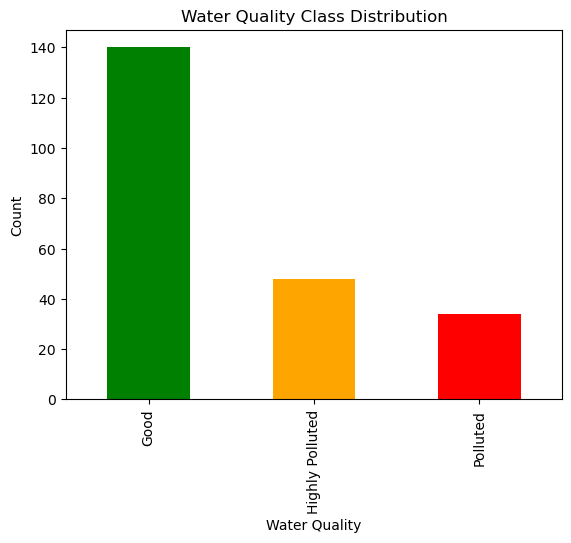

In [34]:
# count of each water quality class
counts = df["Water_Quality"].value_counts()

# bar plot with colors
plt.figure()
counts.plot(
    kind="bar",
    color=["green", "orange", "red", "darkred"]
)

plt.title("Water Quality Class Distribution")
plt.xlabel("Water Quality")
plt.ylabel("Count")
plt.show()


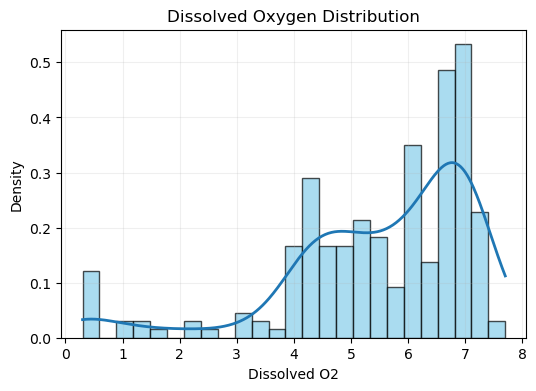

In [35]:
# shows oxygen availability in water samples
# helps identify low-oxygen polluted zones

data = df["Dissolved O2"].dropna()

plt.figure(figsize=(6, 4))

# histogram (thicker bars, fewer bins)
plt.hist(
    data,
    bins=25,                
    density=True,
    color="skyblue",
    edgecolor="black",
    alpha=0.7
)

# smooth distribution curve
kde = gaussian_kde(data, bw_method=0.3)   # smoother curve
x_vals = np.linspace(data.min(), data.max(), 400)
plt.plot(x_vals, kde(x_vals), linewidth=2)

plt.title("Dissolved Oxygen Distribution")
plt.xlabel("Dissolved O2")
plt.ylabel("Density")
plt.grid(alpha=0.2)  # light grid for readability
plt.show()

# insight:
# main peak shows normal oxygen range
# left tail shows polluted low-oxygen zones
# right side shows healthy water zones


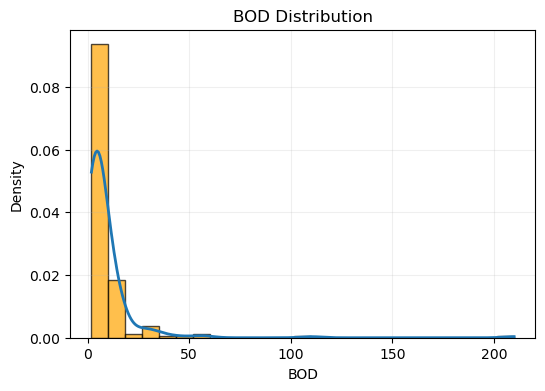

In [36]:
# organic pollution levels
# highlights contaminated water zones

data = df["BOD"].dropna()

plt.figure(figsize=(6, 4))

plt.hist(data, bins=25, density=True, color="orange", edgecolor="black", alpha=0.7)

# smooth curve
kde = gaussian_kde(data, bw_method=0.3)
x_vals = np.linspace(data.min(), data.max(), 300)
plt.plot(x_vals, kde(x_vals), linewidth=2)

plt.title("BOD Distribution")
plt.xlabel("BOD")
plt.ylabel("Density")
plt.grid(alpha=0.2)
plt.show()

# insight:
# most samples = low pollution
# long tail = heavy contamination zones


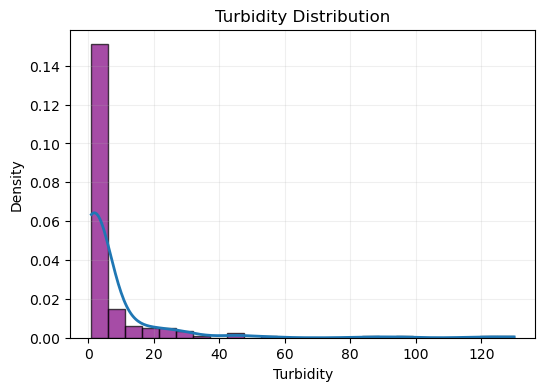

In [37]:
# water clarity levels
# shows suspended particle pollution

data = df["Turbidity"].dropna()

plt.figure(figsize=(6, 4))

plt.hist(data, bins=25, density=True, color="purple", edgecolor="black", alpha=0.7)

# smooth curve
kde = gaussian_kde(data, bw_method=0.3)
x_vals = np.linspace(data.min(), data.max(), 300)
plt.plot(x_vals, kde(x_vals), linewidth=2)

plt.title("Turbidity Distribution")
plt.xlabel("Turbidity")
plt.ylabel("Density")
plt.grid(alpha=0.2)
plt.show()

# insight:
# low values = clear water
# high values = muddy/polluted water


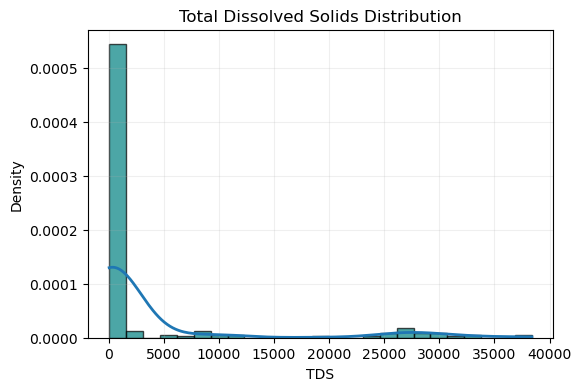

In [38]:
# chemical and salt content in water
# highlights salinity and industrial pollution

data = df["Total Dissolved Solids"].dropna()

plt.figure(figsize=(6, 4))

plt.hist(data, bins=25, density=True, color="teal", edgecolor="black", alpha=0.7)

# smooth curve
kde = gaussian_kde(data, bw_method=0.3)
x_vals = np.linspace(data.min(), data.max(), 300)
plt.plot(x_vals, kde(x_vals), linewidth=2)

plt.title("Total Dissolved Solids Distribution")
plt.xlabel("TDS")
plt.ylabel("Density")
plt.grid(alpha=0.2)
plt.show()

# insight:
# low range = fresh water
# mid range = moderate pollution
# extreme values = saline/industrial zones


Bivariate plots

<Figure size 600x400 with 0 Axes>

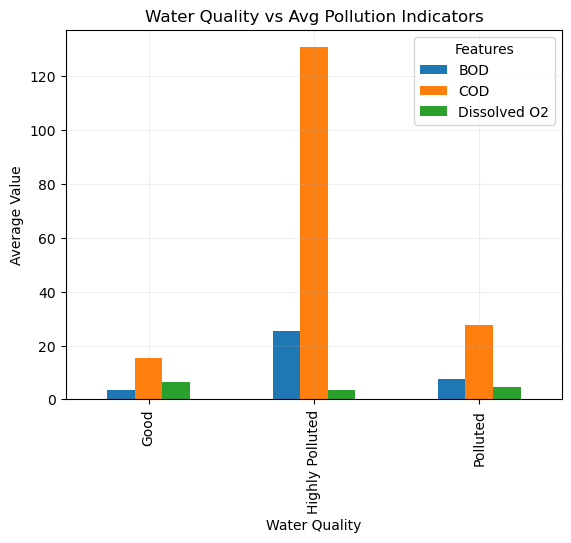

In [39]:
# average feature values per water quality class
# shows how pollution indicators change across quality levels

features = ["BOD", "COD", "Dissolved O2"]

avg_data = df.groupby("Water_Quality")[features].mean()

plt.figure(figsize=(6, 4))

avg_data.plot(kind="bar")

plt.title("Water Quality vs Avg Pollution Indicators")
plt.xlabel("Water Quality")
plt.ylabel("Average Value")
plt.legend(title="Features")
plt.grid(alpha=0.2)
plt.show()

# insight:
# Good → low BOD, low COD, high oxygen
# Moderate → rising pollution indicators
# Poor → high pollution, lower oxygen
# Highly Polluted → extreme BOD/COD, very low oxygen


<Figure size 600x400 with 0 Axes>

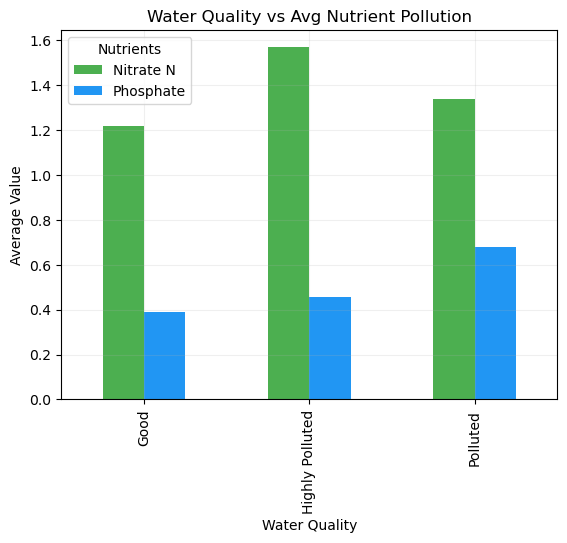

In [40]:
# nutrient pollution impact by water quality
# shows how nutrients increase with pollution level

features = ["Nitrate N", "Phosphate"]
avg_data = df.groupby("Water_Quality")[features].mean()

plt.figure(figsize=(6, 4))

avg_data.plot(kind="bar", color=["#4CAF50", "#2196F3"])

plt.title("Water Quality vs Avg Nutrient Pollution")
plt.xlabel("Water Quality")
plt.ylabel("Average Value")
plt.legend(title="Nutrients")
plt.grid(alpha=0.2)
plt.show()

# insight:
# Good → low nutrients
# Moderate → rising nutrient levels
# Poor → high nutrient pollution
# Highly Polluted → extreme nutrient load


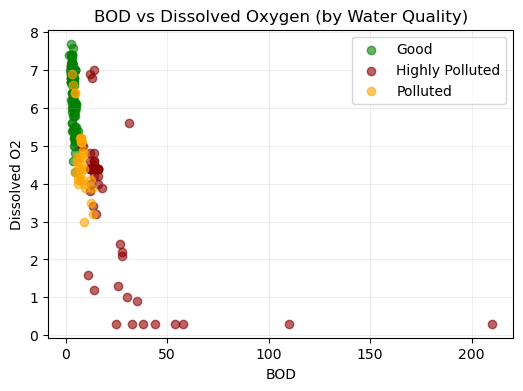

In [42]:
# oxygen vs organic pollution relationship
# shows ecosystem stress due to pollution

plt.figure(figsize=(6, 4))

classes = df["Water_Quality"].unique()
colors = {
    "Good": "green",
    "Polluted": "orange",
    "Highly Polluted": "darkred"
}

for c in classes:
    subset = df[df["Water_Quality"] == c]
    plt.scatter(subset["BOD"], subset["Dissolved O2"], label=c, color=colors[c], alpha=0.6)

plt.title("BOD vs Dissolved Oxygen (by Water Quality)")
plt.xlabel("BOD")
plt.ylabel("Dissolved O2")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# insight:
# Good water → low BOD, high oxygen
# Polluted water → high BOD, low oxygen
# clear class separation pattern


Multi-variate Graphs

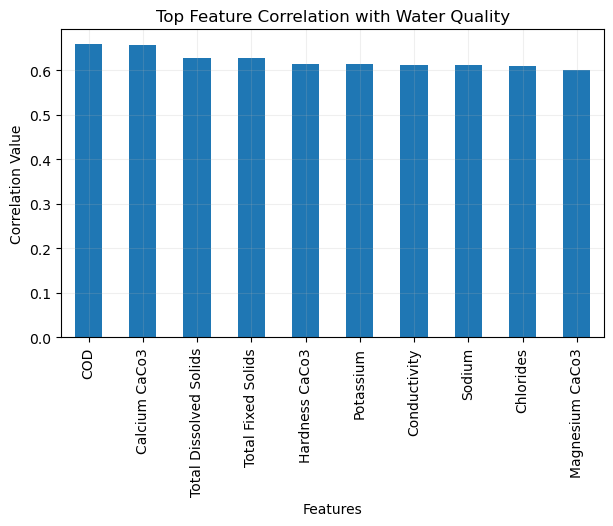

In [43]:
# encode target for correlation
# compute correlation using only numeric columns
corr_vals = df.select_dtypes(include="number").corr()["Water_Quality_Enc"].sort_values(ascending=False)

plt.figure(figsize=(7, 4))
corr_vals.drop("Water_Quality_Enc").head(10).plot(kind="bar")

plt.title("Top Feature Correlation with Water Quality")
plt.xlabel("Features")
plt.ylabel("Correlation Value")
plt.grid(alpha=0.2)
plt.show()

# insight:
# higher bar = stronger relation with water quality
# shows most influential pollution features
# helps feature selection for ML


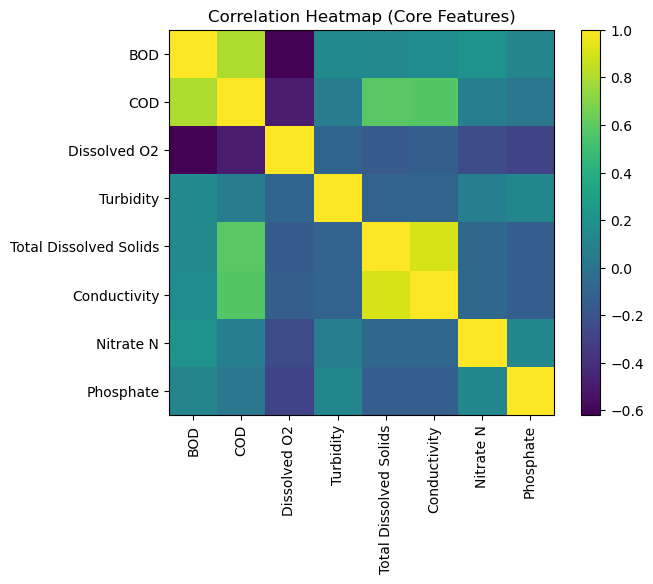

In [44]:
# correlation heatmap for core features
# shows relationships between multiple variables

heat_cols = [
    "BOD", "COD", "Dissolved O2", "Turbidity",
    "Total Dissolved Solids", "Conductivity",
    "Nitrate N", "Phosphate"
]

corr = df[heat_cols].corr()

plt.figure(figsize=(7, 5))

plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(heat_cols)), heat_cols, rotation=90)
plt.yticks(range(len(heat_cols)), heat_cols)

plt.title("Correlation Heatmap (Core Features)")
plt.show()

# insight:
# strong color = strong relationship
# weak color = weak dependency
# helps detect redundant features
# helps understand ML feature interactions


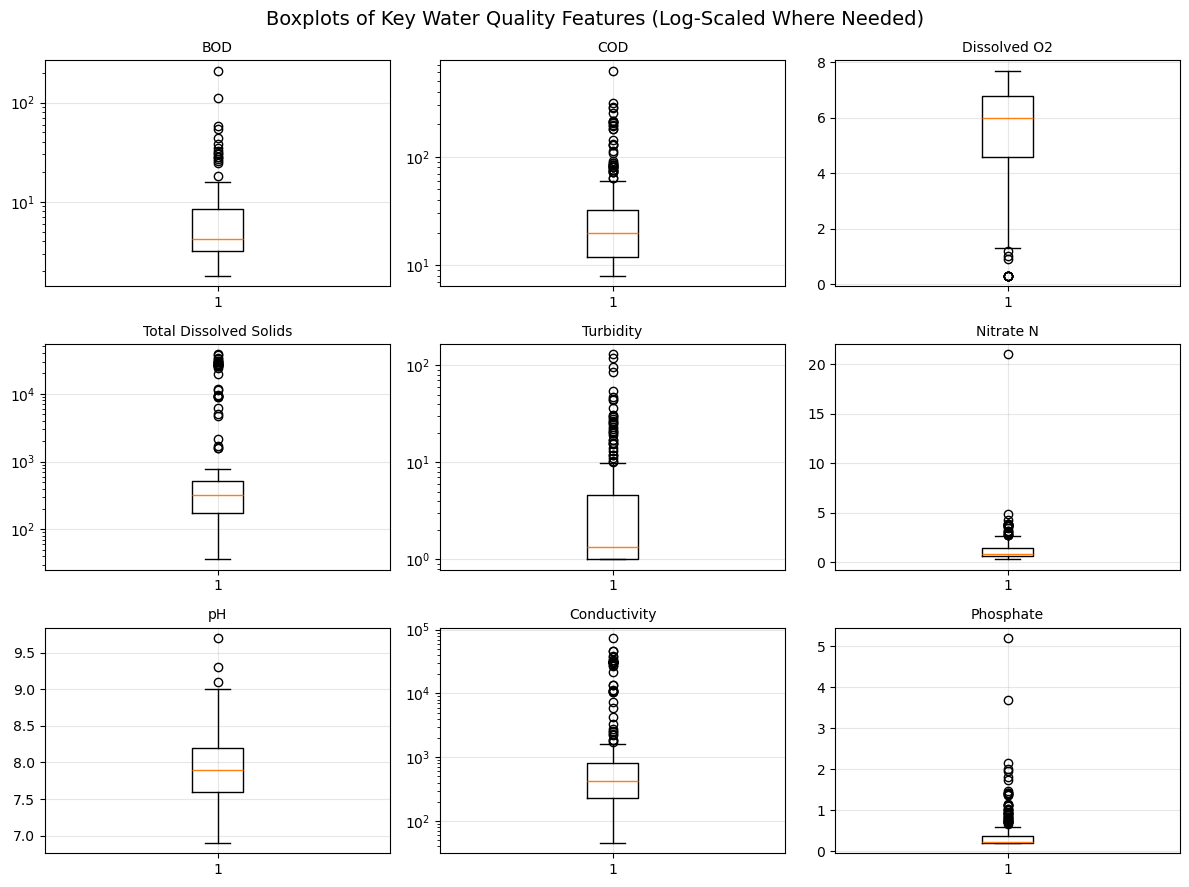

In [45]:
import matplotlib.pyplot as plt

features = [
    "BOD",
    "COD",
    "Dissolved O2",
    "Total Dissolved Solids",
    "Turbidity",
    "Nitrate N",
    "pH",
    "Conductivity",
    "Phosphate"
]

fig, axes = plt.subplots(3, 3, figsize=(12, 9))
axes = axes.flatten()

for i, col in enumerate(features):
    data = df[col].dropna()
    
    axes[i].boxplot(data, vert=True, showfliers=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].grid(alpha=0.3)
    
    # apply log scale only where needed
    if col in ["COD", "Total Dissolved Solids", "Conductivity", "Turbidity", "BOD"]:
        axes[i].set_yscale("log")

plt.suptitle("Boxplots of Key Water Quality Features (Log-Scaled Where Needed)", fontsize=14)
plt.tight_layout()
plt.show()

# insight:
# log scaling fixes compression
# preserves extreme pollution values
# improves readability
# shows real distribution
# keeps scientific correctness
# supports ML feature understanding


Outlier Detection and treating

In [46]:
# IQR-based outlier detection
# robust method for skewed + pollution data

outlier_summary = {}

for col in df.select_dtypes(include="number").columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_summary[col] = len(outliers)

# print outlier count per column
for col, count in outlier_summary.items():
    print(f"{col} → {count} outliers")

# meaning:
# shows how many extreme values exist per feature
# helps understand pollution spikes


Approx Depth → 27 outliers
Temperature → 19 outliers
Dissolved O2 → 11 outliers
pH → 3 outliers
Conductivity → 43 outliers
BOD → 16 outliers
Nitrate N → 22 outliers
Fecal Coliform → 13 outliers
Total Coliform → 23 outliers
Fecal Streptococci → 31 outliers
Turbidity → 35 outliers
Phenophelene Alkanity → 47 outliers
Total Alkalinity → 21 outliers
Chlorides → 37 outliers
COD → 40 outliers
Total Kjeldahl N → 34 outliers
Amonia N → 37 outliers
Hardness CaCo3 → 33 outliers
Calcium CaCo3 → 26 outliers
Magnesium CaCo3 → 33 outliers
Sulphate → 35 outliers
Sodium → 37 outliers
Total Dissolved Solids → 37 outliers
Total Fixed Solids → 37 outliers
Total Suspended Solids → 6 outliers
Phosphate → 45 outliers
Boron → 47 outliers
Potassium → 40 outliers
Flouride → 13 outliers
Water_Quality_Enc → 0 outliers


In [47]:
# check highest values per numeric column
# helps identify extreme pollution spikes

for col in df.select_dtypes(include="number").columns:
    print(f"\n--- Highest values in {col} ---")
    print(df[col].sort_values(ascending=False).head(5))

# meaning:
# shows top extreme values
# helps validate realism
# detects abnormal spikes



--- Highest values in Approx Depth ---
0     125.0
1     125.0
2     125.0
3     125.0
11    125.0
Name: Approx Depth, dtype: float64

--- Highest values in Temperature ---
8     31.0
9     31.0
10    31.0
5     30.0
63    30.0
Name: Temperature, dtype: float64

--- Highest values in Dissolved O2 ---
11     7.7
117    7.6
75     7.4
77     7.4
86     7.4
Name: Dissolved O2, dtype: float64

--- Highest values in pH ---
115    9.7
153    9.3
147    9.1
10     9.0
167    8.7
Name: pH, dtype: float64

--- Highest values in Conductivity ---
115    74240.0
31     47120.0
32     46480.0
66     39010.0
65     37920.0
Name: Conductivity, dtype: float64

--- Highest values in BOD ---
74    210.0
73    110.0
72     58.0
71     54.0
54     44.0
Name: BOD, dtype: float64

--- Highest values in Nitrate N ---
72     21.00
147     4.92
148     4.28
143     3.83
140     3.82
Name: Nitrate N, dtype: float64

--- Highest values in Fecal Coliform ---
125    1600.0
124    1600.0
51     1400.0
183     540.

In [48]:
# check lowest values per numeric column
# helps detect impossible or invalid low values

for col in df.select_dtypes(include="number").columns:
    print(f"\n--- Lowest values in {col} ---")
    print(df[col].sort_values(ascending=True).head(5))

# meaning:
# detects negative values
# detects zero where impossible
# finds sensor/data errors



--- Lowest values in Approx Depth ---
5     25.0
4     25.0
14    25.0
15    25.0
13    25.0
Name: Approx Depth, dtype: float64

--- Lowest values in Temperature ---
11     18.0
131    18.0
172    18.0
173    18.0
132    18.0
Name: Temperature, dtype: float64

--- Lowest values in Dissolved O2 ---
51     0.3
54     0.3
126    0.3
125    0.3
72     0.3
Name: Dissolved O2, dtype: float64

--- Lowest values in pH ---
74     6.9
63     7.1
99     7.1
158    7.1
60     7.2
Name: pH, dtype: float64

--- Lowest values in Conductivity ---
212    45.0
99     55.0
28     75.0
38     84.0
39     89.0
Name: Conductivity, dtype: float64

--- Lowest values in BOD ---
101    1.8
62     2.0
38     2.4
214    2.4
34     2.6
Name: BOD, dtype: float64

--- Lowest values in Nitrate N ---
29    0.3
28    0.3
41    0.3
39    0.3
36    0.3
Name: Nitrate N, dtype: float64

--- Lowest values in Fecal Coliform ---
0    1.8
1    1.8
2    1.8
3    1.8
4    1.8
Name: Fecal Coliform, dtype: float64

--- Lowest val

In [49]:
# -------------------------------
# Standard reference ranges
# -------------------------------

standards = {
    "pH": {
        "drinking": (6.5, 8.5),
        "sewage": (6.0, 9.0)
    },
    "Dissolved O2": {
        "drinking": (6, 9),
        "sewage": (0, 2)
    },
    "BOD": {
        "drinking": (0, 2),
        "sewage": (100, 300)
    },
    "COD": {
        "drinking": (0, 10),
        "sewage": (250, 1000)
    },
    "Turbidity": {
        "drinking": (0, 5),
        "sewage": (50, 300)
    },
    "Total Dissolved Solids": {
        "drinking": (0, 500),
        "sewage": (2000, 40000)
    },
    "Conductivity": {
        "drinking": (0, 1500),
        "sewage": (5000, 100000)
    },
    "Nitrate N": {
        "drinking": (0, 45),
        "sewage": (50, 200)
    },
    "Phosphate": {
        "drinking": (0, 0.1),
        "sewage": (1, 10)
    },
    "Flouride": {
        "drinking": (0, 1.5),
        "sewage": (1.5, 5)
    }
}

# -------------------------------
# Print report
# -------------------------------

for col, ranges in standards.items():
    if col in df.columns:

        print("\n" + "="*60)
        print(f"🧪 {col}")
        print("="*60)

        print(f"Drinking Water Range : {ranges['drinking'][0]}  –  {ranges['drinking'][1]}")
        print(f"Sewage Water Range   : {ranges['sewage'][0]}  –  {ranges['sewage'][1]}")

        print("\nBottom 5 values from dataset:")
        print(df[col].dropna().sort_values().head(5).to_list())

        print("\nTop 5 values from dataset:")
        print(df[col].dropna().sort_values(ascending=False).head(5).to_list())



🧪 pH
Drinking Water Range : 6.5  –  8.5
Sewage Water Range   : 6.0  –  9.0

Bottom 5 values from dataset:
[6.9, 7.1, 7.1, 7.1, 7.2]

Top 5 values from dataset:
[9.7, 9.3, 9.1, 9.0, 8.7]

🧪 Dissolved O2
Drinking Water Range : 6  –  9
Sewage Water Range   : 0  –  2

Bottom 5 values from dataset:
[0.3, 0.3, 0.3, 0.3, 0.3]

Top 5 values from dataset:
[7.7, 7.6, 7.4, 7.4, 7.4]

🧪 BOD
Drinking Water Range : 0  –  2
Sewage Water Range   : 100  –  300

Bottom 5 values from dataset:
[1.8, 2.0, 2.4, 2.4, 2.6]

Top 5 values from dataset:
[210.0, 110.0, 58.0, 54.0, 44.0]

🧪 COD
Drinking Water Range : 0  –  10
Sewage Water Range   : 250  –  1000

Bottom 5 values from dataset:
[8.0, 8.0, 8.0, 8.0, 8.0]

Top 5 values from dataset:
[624.0, 312.0, 288.0, 280.0, 252.0]

🧪 Turbidity
Drinking Water Range : 0  –  5
Sewage Water Range   : 50  –  300

Bottom 5 values from dataset:
[1.0, 1.0, 1.0, 1.0, 1.0]

Top 5 values from dataset:
[130.0, 120.0, 95.0, 85.0, 55.0]

🧪 Total Dissolved Solids
Drinking Water 

Data splitting

In [74]:
# separating features and target
X = df.drop(columns=["Water_Quality", "Water_Quality_Enc"])
y = df["Water_Quality_Enc"]


In [75]:
#spilitting data for train and test dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


SVM model

In [76]:
#creating pipeline for svm model 
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),   # standardizes features for distance-based learning
    ("svm", SVC(kernel="rbf", C=1, gamma="scale", probability=True))  # SVM classifier
])

In [77]:
# training the SVM model
svm_pipeline.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(C=1, probability=True))])

In [78]:
# predictions on test set
y_pred_svm = svm_pipeline.predict(X_test)


In [ ]:
SVM validation

In [79]:
# accuracy score
acc = accuracy_score(y_test, y_pred_svm)

# classification performance
print("SVM Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))

# confusion matrix
cm = confusion_matrix(y_test, y_pred_svm)

SVM Accuracy: 0.8444444444444444

Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.97        28
           1       0.50      0.29      0.36         7
           2       0.73      0.80      0.76        10

    accuracy                           0.84        45
   macro avg       0.72      0.70      0.70        45
weighted avg       0.82      0.84      0.83        45



SVM balanaced 

In [81]:
#becz we have imabalanced data set we made class weights as balanced
svm_pipeline_balanced = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=1,
        gamma="scale",
        class_weight="balanced",   # handles class imbalance
        probability=True
    ))
])

# train balanced model
svm_pipeline_balanced.fit(X_train, y_train)

# predict
y_pred_svm_bal = svm_pipeline_balanced.predict(X_test)


SVM balanced validation

In [82]:
print("\nBalanced SVM Classification Report:\n")
print(classification_report(y_test, y_pred_svm_bal))


Balanced SVM Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.86      0.92        28
           1       0.45      0.71      0.56         7
           2       0.80      0.80      0.80        10

    accuracy                           0.82        45
   macro avg       0.75      0.79      0.76        45
weighted avg       0.87      0.82      0.84        45



XGBoost model and validation

In [83]:
xgb_model = XGBClassifier(
    objective="multi:softprob",   # multi-class classification
    num_class=3,                  # Good, Polluted, Highly Polluted
    eval_metric="mlogloss",
    use_label_encoder=False,
    random_state=42
)

# Train model
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

# Evaluation
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", acc_xgb)
print("\nXGBoost Classification Report:\n")
print(classification_report(y_test, y_pred_xgb))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

XGBoost Accuracy: 0.9777777777777777

XGBoost Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       0.88      1.00      0.93         7
           2       1.00      0.90      0.95        10

    accuracy                           0.98        45
   macro avg       0.96      0.97      0.96        45
weighted avg       0.98      0.98      0.98        45



Cross validation

In [86]:
#cross validation since we had high accuracy and precision checking for overfitting
# XGBoost model configuration
xgb_model = XGBClassifier(
    objective="multi:softprob",   # multi-class classification
    num_class=3,                  # Good, Polluted, Highly Polluted
    eval_metric="mlogloss",       # multi-class log loss
    n_estimators=300,             # number of trees
    learning_rate=0.05,           # step size shrinkage
    max_depth=6,                  # tree depth
    subsample=0.9,                # row sampling
    colsample_bytree=0.9,         # feature sampling
    random_state=42
)


In [89]:
# stratified k-fold keeps class ratio same in each fold
skf = StratifiedKFold(
    n_splits=5,        # 5-fold cross validation
    shuffle=True,     # shuffle for randomness
    random_state=42
)


In [91]:
# cross-validation accuracy scores
cv_scores = cross_val_score(
    xgb_model,
    X,                # features
    y,            # encoded target
    cv=skf,
    scoring="accuracy"
)


Cross validation scores

In [92]:
print("Cross-Validation Scores:", cv_scores)

print("\nMean CV Accuracy:", cv_scores.mean())
print("Std CV Accuracy:", cv_scores.std())


Cross-Validation Scores: [0.91111111 0.95555556 0.97727273 0.97727273 0.97727273]

Mean CV Accuracy: 0.9596969696969697
Std CV Accuracy: 0.02570781487680801


Hyperparameter Tuning

In [94]:
# base XGBoost model
xgb_base = XGBClassifier(
    objective="multi:softprob",   # multi-class classification
    num_class=3,                  # Good, Polluted, Highly Polluted
    eval_metric="mlogloss",       # multi-class loss
    random_state=42
)


In [95]:
# hyperparameter search space
param_dist = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.2, 0.3],
    "min_child_weight": [1, 3, 5, 7]
}


In [96]:
# randomized search with cross-validation
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,                 # number of random combinations
    scoring="accuracy",        # evaluation metric
    cv=5,                      # 5-fold CV
    verbose=2,                 # progress logs
    random_state=42,
    n_jobs=-1                  # use all CPU cores
)


In [97]:
# run hyperparameter tuning
random_search.fit(X, y)


Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='mlogloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_con...
                                           n_estimators=None, n_jobs=None,
                                           num_class=3, ...),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.2, 0.3],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1],
                                        'max_depth': [3, 4, 5, 6, 7, 8],
                                        'min_child_weight': [1, 3, 5, 7],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='accuracy', verbose=2)

Hyperparameter tuning validation

In [98]:
print("Best Parameters Found:")
print(random_search.best_params_)

print("\nBest CV Accuracy:")
print(random_search.best_score_)


Best Parameters Found:
{'subsample': 0.9, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 0.9}

Best CV Accuracy:
0.9056565656565656


model deployment

In [99]:
# Final training on full dataset
final_xgb = xgb_model   # baseline model (best performing)
final_xgb.fit(X, y)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=3, ...)

In [100]:
# label decoding map for deployment
label_map = {
    0: "Good",
    1: "Polluted",
    2: "Highly Polluted"
}


In [101]:
import joblib

# save model
joblib.dump(final_xgb, "water_quality_xgb_model.pkl")

# save label mapping
joblib.dump(label_map, "label_mapping.pkl")

# save feature columns order ( important for inference)
joblib.dump(list(X.columns), "feature_columns.pkl")


['feature_columns.pkl']